# 04 · Compare policy rules with an interpretable model

**Question:** Can a shallow tree reproduce scenario routing, and what does it learn when the referral is incomplete?

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
get_ipython().run_line_magic('matplotlib', 'inline')

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
DATA = ROOT / 'data/synthetic/transfer_requests.csv'
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False, 'axes.spines.right': False})


In [2]:
from transfer_assistant.extraction import RuleBasedExtractor
from transfer_assistant.modeling import feature_frame, train_model, FEATURES
from transfer_assistant.routing import recommend
from transfer_assistant.schema import ROUTES
from sklearn.metrics import classification_report
from sklearn.tree import export_text
data = pd.read_csv(DATA)
extractor = RuleBasedExtractor()
parsed = [extractor.extract(n) for n in data.free_text_transfer_note]
x = feature_frame(parsed)
train, validation = data.split.eq('train'), data.split.eq('validation')
model, selection = train_model(x[train],data.routing_target[train],x[validation],data.routing_target[validation])
display(selection)
print('Input features:', FEATURES)

{'selected_depth': 6,
 'candidates': [{'max_depth': 3, 'validation_macro_f1': 0.9093425938038505},
  {'max_depth': 4, 'validation_macro_f1': 0.9838537287621417},
  {'max_depth': 5, 'validation_macro_f1': 0.9838537287621417},
  {'max_depth': 6, 'validation_macro_f1': 0.9921893775534727}]}

Input features: ['oxygen_support', 'vasopressor_use', 'monitoring_required', 'specialty_need', 'requested_service', 'systolic_bp', 'heart_rate', 'spo2']


## Model selection without test fitting
Training-only one-hot encoding and median imputation feed a class-weighted decision tree, with depth selected on validation macro-F1. Missing categorical values are explicit `unknown`; numerical imputation adds missingness indicators. The model excludes age, facility, capacity, requested bed, IDs, and outcomes.

In [3]:
y = data.routing_target[validation]
rules = [recommend(r).route for r,use in zip(parsed,validation) if use]
print('RULES: validation')
print(classification_report(y,rules,labels=ROUTES,zero_division=0))
print('TREE: validation')
print(classification_report(y,model.predict(x[validation]),labels=ROUTES,zero_division=0))

RULES: validation
                  precision    recall  f1-score   support

             ICU       1.00      0.87      0.93        30
       telemetry       1.00      0.63      0.78        30
medical/surgical       1.00      0.53      0.69        36
specialty review       1.00      0.83      0.91        29

       micro avg       1.00      0.70      0.83       125
       macro avg       1.00      0.71      0.83       125
    weighted avg       1.00      0.70      0.82       125

TREE: validation
                  precision    recall  f1-score   support

             ICU       1.00      1.00      1.00        30
       telemetry       1.00      1.00      1.00        30
medical/surgical       0.97      1.00      0.99        36
specialty review       1.00      0.97      0.98        29

        accuracy                           0.99       125
       macro avg       0.99      0.99      0.99       125
    weighted avg       0.99      0.99      0.99       125



|--- categorical__specialty_need_True <= 0.50
|   |--- categorical__monitoring_required_False <= 0.50
|   |   |--- categorical__oxygen_support_room air <= 0.50
|   |   |   |--- numeric__heart_rate <= 94.50
|   |   |   |   |--- numeric__heart_rate <= 78.00
|   |   |   |   |   |--- class: telemetry
|   |   |   |   |--- numeric__heart_rate >  78.00
|   |   |   |   |   |--- class: telemetry
|   |   |   |--- numeric__heart_rate >  94.50
|   |   |   |   |--- categorical__requested_service_cardiology <= 0.50
|   |   |   |   |   |--- categorical__oxygen_support_unknown <= 0.50
|   |   |   |   |   |   |--- class: ICU
|   |   |   |   |   |--- categorical__oxygen_support_unknown >  0.50
|   |   |   |   |   |   |--- class: ICU
|   |   |   |   |--- categorical__requested_service_cardiology >  0.50
|   |   |   |   |   |--- numeric__systolic_bp <= 106.50
|   |   |   |   |   |   |--- class: ICU
|   |   |   |   |   |--- numeric__systolic_bp >  106.50
|   |   |   |   |   |   |--- class: telemetry
|   | 

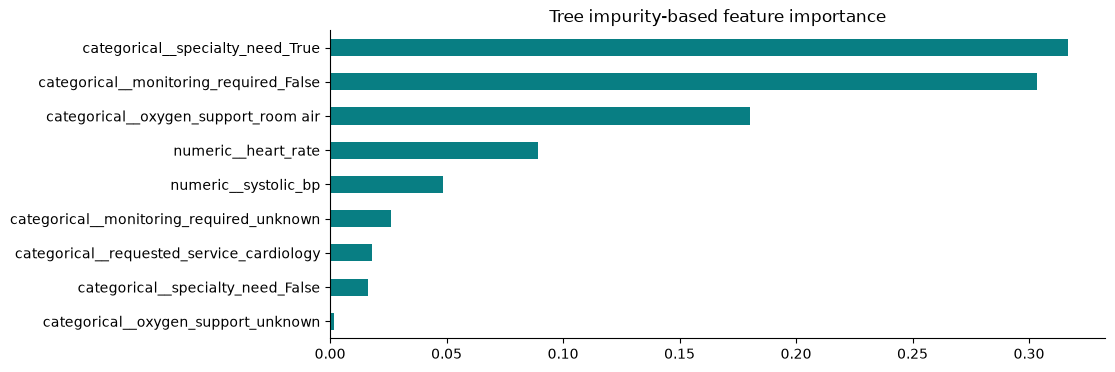

In [4]:
names = model.named_steps['preprocess'].get_feature_names_out()
print(export_text(model.named_steps['tree'],feature_names=list(names)))
importance = pd.Series(model.named_steps['tree'].feature_importances_,index=names).sort_values()
importance[importance>0].plot.barh(color='#087E83',title='Tree impurity-based feature importance')
plt.show()

In [5]:
from transfer_assistant.modeling import explain_tree
from transfer_assistant.examples import EXAMPLES
incomplete = extractor.extract(EXAMPLES['Incomplete referral'])
display({'rules':recommend(incomplete).route,'tree':explain_tree(model,incomplete)})

{'rules': 'insufficient information',
 'tree': {'route': 'ICU',
  'decision_path': ['categorical__specialty_need_True = 0.00 <= 0.50',
   'categorical__monitoring_required_False = 0.00 <= 0.50',
   'categorical__oxygen_support_room air = 0.00 <= 0.50',
   'numeric__heart_rate = 95.00 > 94.50',
   'categorical__requested_service_cardiology = 0.00 <= 0.50',
   'categorical__oxygen_support_unknown = 1.00 > 0.50'],
  'leaf_class_weights': {'ICU': 0.7970244420828905,
   'medical/surgical': 0.0,
   'specialty review': 0.0,
   'telemetry': 0.2029755579171095},
  'caution': 'Class-weighted leaf proportions are uncalibrated and are not clinical confidence.'}}

## Tradeoff
The tree can use correlated service and vitals to fill an inferential gap; the deterministic workflow can withhold a lower-acuity recommendation. Full model coverage is not evidence that missing facts were recovered. Tree leaf proportions are uncalibrated, particularly with balanced class weights. The app keeps the tree as a comparison.